In [ ]:
# Cell 1
import stable_worldmodel as swm
world = swm.World("swm/PushT-v1", num_envs=8, image_shape=(64, 64))


# Cell 2
random_policy = swm.policy.RandomPolicy(seed=44)
world.set_policy(random_policy)

world.collect(
    "data/pusht_demo.lance",
    episodes=100,
    seed=0,
    mode='overwrite',
)
print("Done collecting!")


Recording: 100%|██████████| 100/100 [00:22<00:00,  4.51it/s]

Done collecting!


In [35]:
# Cell 3: Load dataset and inspect
import os
abs_path = os.path.abspath("data/pusht_demo.lance")
print(abs_path)
print(os.path.exists(abs_path))



dataset = swm.data.load_dataset(
    abs_path,
    frameskip=1,
    num_steps=64,
    keys_to_load=["pixels", "action", "state"],
)

sample = dataset[0]
print(f"Number of samples in dataset: {len(dataset)}")
print(f"Sample pixels shape: {sample['pixels'].shape}")
print(f"Sample action shape: {sample['action'].shape}")

/workspace/swm-runpod/data/pusht_demo.lance
True
Number of samples in dataset: 3700
Sample pixels shape: torch.Size([64, 3, 64, 64])
Sample action shape: torch.Size([64, 2])


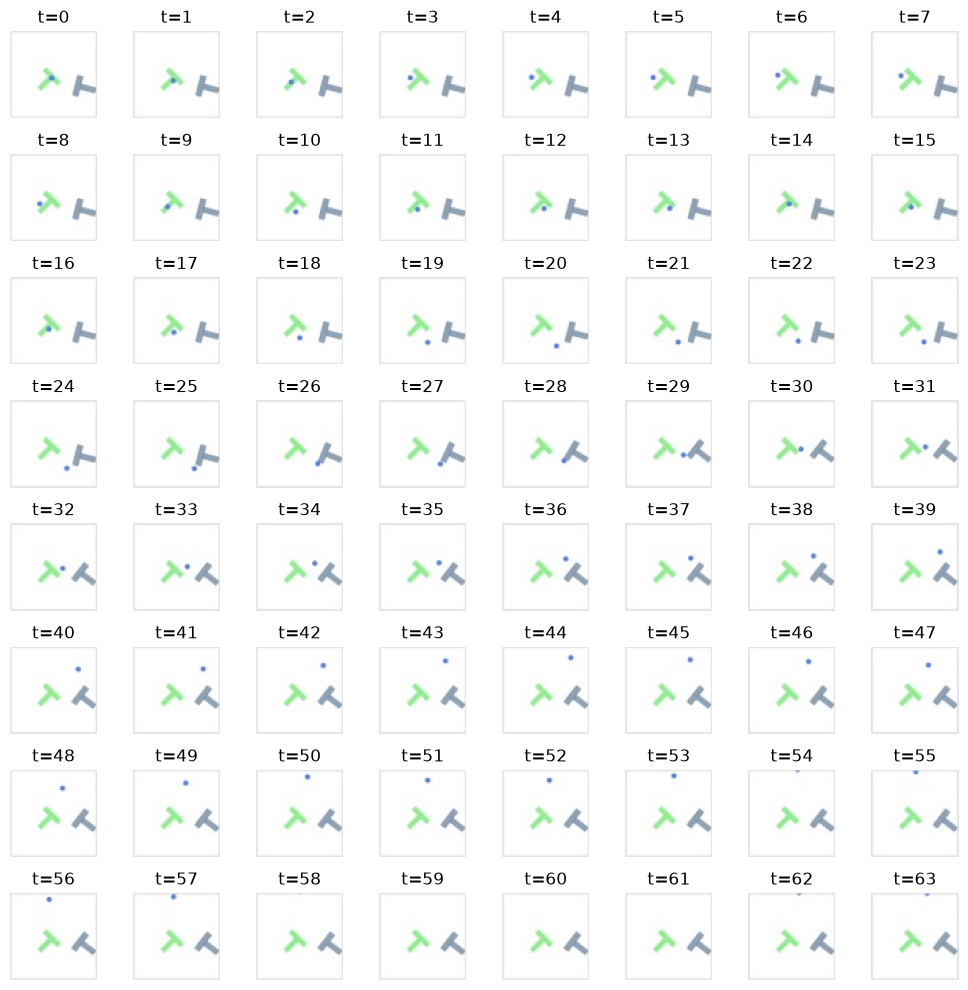

Saved to sample_trajectory.png


In [36]:
# Cell: visualize a sample trajectory
import matplotlib.pyplot as plt
import numpy as np

sample = dataset[0]
pixels = sample['pixels']  # (16, 3, 64, 64)

# Show every 2nd frame (8 frames total) in a row
num_frames_to_show = 64
step = pixels.shape[0] // num_frames_to_show

fig, axes = plt.subplots(8, num_frames_to_show // 8, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    frame_idx = i * step
    img = pixels[frame_idx].permute(1, 2, 0).numpy()  # (H, W, C)
    
    # Normalize if needed (pixels might be 0-1 float or 0-255)
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    
    ax.imshow(img)
    ax.set_title(f"t={frame_idx}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('/workspace/swm-runpod/sample_trajectory.png', dpi=100)
plt.show()
print("Saved to sample_trajectory.png")